In [1]:
import pandas as pd

In [46]:
local_raw_df=pd.read_csv(r'Prod_data\tbl_device_history.csv')

In [47]:
local_raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 299120 entries, 0 to 299119
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   historyId       299120 non-null  int64  
 1   deviceEndpoint  299120 non-null  str    
 2   latitude        299120 non-null  float64
 3   longitude       299120 non-null  float64
 4   trolleyId       299120 non-null  int64  
 5   geozoneId       299120 non-null  int64  
 6   geolayerId      299120 non-null  int64  
 7   createdOn       299120 non-null  str    
 8   modifiedOn      26011 non-null   str    
 9   status          299120 non-null  int64  
 10  nestId          299120 non-null  int64  
 11  wifiRTT         299120 non-null  str    
 12  locationSource  299120 non-null  str    
 13  address         166210 non-null  str    
dtypes: float64(2), int64(6), str(6)
memory usage: 106.4 MB


In [45]:
local_raw_sorted_sorted_sorted_sorted_df.head(1)

,historyId,deviceEndpoint,latitude,longitude,trolleyId,geozoneId,geolayerId,createdOn,modifiedOn,status,nestId,wifiRTT,locationSource,address
0,1,TR1-B43A4535C59C,2.754915,101.703118,1,11,7,2026-03-04 13:35:04,NaN,1,0,[SSID:BC1-F412FA8990B9 BSSID:F4:12:FA:89:90:B9...,Wi-Fi,"Short Term Car Park 'B', Jalan CTA 2, Sepang, ..."


In [ ]:
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()

HOST=os.getenv("DB_HOST")
USER=os.getenv("DB_USER")
PASSWORD=os.getenv("DB_PASSWORD")
DATABASE='demand_forcast_for_trolley'

###=========sqlAlchemy========
engine = create_engine(
    f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:3306/{DATABASE}"
)

print("Connected using SQLAlchemy!")

Connected using SQLAlchemy!


In [48]:
# Insert dataframe into existing table
local_raw_df.to_sql(
    name="tbl_device_history",
    con=engine,
    if_exists="replace",   # IMPORTANT → does not recreate table
    index=False
)

299120

In [49]:
df=pd.read_sql('select * from tbl_device_history',engine)

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 299120 entries, 0 to 299119
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   historyId       299120 non-null  int64  
 1   deviceEndpoint  299120 non-null  str    
 2   latitude        299120 non-null  float64
 3   longitude       299120 non-null  float64
 4   trolleyId       299120 non-null  int64  
 5   geozoneId       299120 non-null  int64  
 6   geolayerId      299120 non-null  int64  
 7   createdOn       299120 non-null  str    
 8   modifiedOn      26011 non-null   str    
 9   status          299120 non-null  int64  
 10  nestId          299120 non-null  int64  
 11  wifiRTT         299120 non-null  str    
 12  locationSource  299120 non-null  str    
 13  address         166210 non-null  str    
dtypes: float64(2), int64(6), str(6)
memory usage: 106.4 MB


In [51]:
df['trolleyId'].unique()

array([  1,   2,   7,   6,   5,   3,   9,   8,   4,  10,  70,  20,  83,
        31,  51,  82,  29,  79,  68,  67,  38,  11,  47,  22,  85,  24,
        33,  44,  28,  53,  21,  16,  27,  69,  13,  81,  61,  96,  39,
        32,  37,  54,  75,  77,  91,  87,  66,  86,  46,  74,  18,  23,
        52,  12,  59,  42,  73,  19,  93,  56,  55,  35,  50,  30,  63,
        89,  43,  40,  36,  15,  41,  57,  71,  76,  25,  88,  49,  92,
        45,  48,  64, 100,  78,  84,  65,  90,  62, 101, 102, 103, 104,
       105, 219, 216, 299, 300, 209, 183, 274, 268, 168, 196, 212, 192,
       178, 141, 295, 271, 229, 121, 243, 112, 147, 132, 180, 288, 149,
       158, 238, 249, 138, 224, 205, 273, 254, 176, 235, 208, 137, 234,
       301, 109, 220, 130, 289, 200, 257, 261, 181, 174, 251, 256, 233,
       283, 151, 302, 304, 262, 179,  72, 225, 259, 303, 185, 142, 241,
        98, 305,  60, 306, 309, 308, 314, 307, 310, 323, 313, 328, 312,
       337, 321, 339, 331, 330, 315, 326, 344, 319, 340, 325, 33

<Axes: ylabel='trolleyId'>

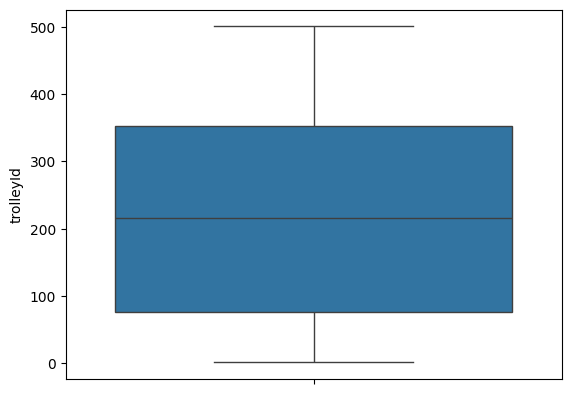

In [52]:
import seaborn as sns

sns.boxplot(df['trolleyId'])

In [66]:
query = """
SELECT 
    historyId,
    trolleyId,
    geozoneId,
    geolayerId,
    createdOn
FROM tbl_device_history
ORDER BY 
    trolleyId ASC,
    STR_TO_DATE(createdOn, '%%d-%%m-%%Y %%H:%%i') ASC;
"""

In [ ]:
sorted_df = pd.read_sql(query, engine)

In [68]:
sorted_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 299120 entries, 0 to 299119
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   historyId   299120 non-null  int64
 1   trolleyId   299120 non-null  int64
 2   geozoneId   299120 non-null  int64
 3   geolayerId  299120 non-null  int64
 4   createdOn   299120 non-null  str  
dtypes: int64(4), str(1)
memory usage: 16.8 MB


In [69]:
sorted_df.head()

,historyId,trolleyId,geozoneId,geolayerId,createdOn
0,297886,1,16,11,2026-05-11 00:51:34
1,298175,1,16,11,2026-05-11 01:51:30
2,298485,1,16,11,2026-05-11 02:51:32
3,298814,1,16,11,2026-05-11 03:51:21
4,294465,1,9,6,2026-05-10 13:48:06


# datetime splitting

In [71]:
sorted_df['createdOn'] = pd.to_datetime(sorted_df['createdOn'])

In [72]:
sorted_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 299120 entries, 0 to 299119
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   historyId   299120 non-null  int64         
 1   trolleyId   299120 non-null  int64         
 2   geozoneId   299120 non-null  int64         
 3   geolayerId  299120 non-null  int64         
 4   createdOn   299120 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(4)
memory usage: 11.4 MB


In [73]:
sorted_df['date'] = sorted_df['createdOn'].dt.date
sorted_df['time'] = sorted_df['createdOn'].dt.time

In [75]:
sorted_df.drop(columns=['createdOn'], inplace=True)

In [77]:
sorted_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 299120 entries, 0 to 299119
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   historyId   299120 non-null  int64 
 1   trolleyId   299120 non-null  int64 
 2   geozoneId   299120 non-null  int64 
 3   geolayerId  299120 non-null  int64 
 4   date        299120 non-null  object
 5   time        299120 non-null  object
dtypes: int64(4), object(2)
memory usage: 13.7+ MB


In [76]:
sorted_df.head()

,historyId,trolleyId,geozoneId,geolayerId,date,time
0,297886,1,16,11,2026-05-11,00:51:34
1,298175,1,16,11,2026-05-11,01:51:30
2,298485,1,16,11,2026-05-11,02:51:32
3,298814,1,16,11,2026-05-11,03:51:21
4,294465,1,9,6,2026-05-10,13:48:06


In [78]:
sorted_df = sorted_df.sort_values(by=['trolleyId', 'date', 'time'], ascending=[True, True, True])

In [81]:
sorted_df.head(100)

,historyId,trolleyId,geozoneId,geolayerId,date,time
314,1,1,11,7,2026-03-04,13:35:04
315,3,1,11,7,2026-03-04,13:37:14
316,8,1,11,7,2026-03-04,13:40:18
317,16,1,11,7,2026-03-04,13:42:16
318,20,1,11,7,2026-03-04,13:44:23
...,...,...,...,...,...,...
409,895,1,16,11,2026-03-04,17:58:41
410,904,1,16,11,2026-03-04,18:01:23
411,914,1,16,11,2026-03-04,18:04:36
412,921,1,16,11,2026-03-04,18:06:55


In [82]:
sorted_df.to_csv("forcast_demand_for_trolley.csv", index=False)

In [83]:
sorted_df.head()

,historyId,trolleyId,geozoneId,geolayerId,date,time
314,1,1,11,7,2026-03-04,13:35:04
315,3,1,11,7,2026-03-04,13:37:14
316,8,1,11,7,2026-03-04,13:40:18
317,16,1,11,7,2026-03-04,13:42:16
318,20,1,11,7,2026-03-04,13:44:23


In [85]:
df=pd.read_csv(r'forcast_demand_for_trolley.csv')

In [ ]:
# ── 2. PARSE DATETIME ─────────────────────────────────────────────────
sorted_df['datetime'] = pd.to_datetime(sorted_df['date'].astype(str) + ' ' + sorted_df['time'].astype(str))
sorted_df = sorted_df.sort_values(['trolleyId', 'datetime']).reset_index(drop=True)


In [ ]:
sorted_df.head()

,historyId,trolleyId,geozoneId,geolayerId,date,time,datetime
0,1,1,11,7,2026-03-04,13:35:04,2026-03-04 13:35:04
1,3,1,11,7,2026-03-04,13:37:14,2026-03-04 13:37:14
2,8,1,11,7,2026-03-04,13:40:18,2026-03-04 13:40:18
3,16,1,11,7,2026-03-04,13:42:16,2026-03-04 13:42:16
4,20,1,11,7,2026-03-04,13:44:23,2026-03-04 13:44:23


In [ ]:
# ── 3. STAY COMPRESSION ───────────────────────────────────────────────
# Detect when geozone changes for the same trolley
sorted_df['zone_changed'] = (
    (sorted_df['trolleyId'] != sorted_df['trolleyId'].shift(1)) |
    (sorted_df['geozoneId'] != sorted_df['geozoneId'].shift(1))
)
sorted_df['stay_id'] = sorted_df['zone_changed'].cumsum()

# Collapse each run into one stay record
stays_raw = sorted_df.groupby('stay_id').agg(
    trolleyId  = ('trolleyId',  'first'),
    geozoneId  = ('geozoneId',  'first'),
    geolayerId = ('geolayerId', 'first'),
    enter_time = ('datetime',   'min'),
    exit_time  = ('datetime',   'max'),
    ping_count = ('historyId',  'count')
).reset_index(drop=True)

# Duration in minutes
stays_raw['duration_mins'] = (
    (stays_raw['exit_time'] - stays_raw['enter_time'])
    .dt.total_seconds() / 60
).round(1)

# Flag idle trolleys (parked >= 2 hours)
stays_raw['is_long_stay'] = (stays_raw['duration_mins'] >= 120).astype(int)

# Remove transit rows (geozoneId == 0 means between zones)
stays = stays_raw[stays_raw['geozoneId'] != 0].copy().reset_index(drop=True)

print(f"\nStay records: {len(stays)}")
print(stays[['trolleyId','geozoneId','enter_time','exit_time','duration_mins']].to_string())


Stay records: 17733
       trolleyId  geozoneId          enter_time           exit_time  duration_mins
0              1         11 2026-03-04 13:35:04 2026-03-04 13:51:17           16.2
1              1          2 2026-03-04 14:01:24 2026-03-04 14:13:10           11.8
2              1          3 2026-03-04 14:29:35 2026-03-04 14:40:16           10.7
3              1          5 2026-03-04 14:41:54 2026-03-04 14:57:54           16.0
4              1          7 2026-03-04 14:59:52 2026-03-04 15:08:29            8.6
5              1          6 2026-03-04 15:09:55 2026-03-04 15:13:30            3.6
6              1          8 2026-03-04 15:15:51 2026-03-04 15:21:41            5.8
7              1          9 2026-03-04 15:26:23 2026-03-04 15:27:42            1.3
8              1         11 2026-03-04 15:33:41 2026-03-04 15:42:26            8.8
9              1         10 2026-03-04 15:43:48 2026-03-04 15:49:52            6.1
10             1         13 2026-03-04 15:51:11 2026-03-04 15:59:5

In [89]:
# ── 4. EXPAND STAYS INTO HOURLY SLOTS ────────────────────────────────
# For each stay, find every 1-hour slot it overlaps

min_slot = stays['enter_time'].min().floor('h')
max_slot = stays['exit_time'].max().ceil('h')
all_slots = pd.date_range(start=min_slot, end=max_slot, freq='1h')

records = []
for _, row in stays.iterrows():
    for slot_start in all_slots:
        slot_end = slot_start + pd.Timedelta(hours=1)
        # A stay overlaps a slot if: enter < slot_end AND exit > slot_start
        if row['enter_time'] < slot_end and row['exit_time'] > slot_start:
            records.append({
                'trolleyId'  : row['trolleyId'],
                'geozoneId'  : row['geozoneId'],
                'geolayerId' : row['geolayerId'],
                'slot_start' : slot_start,
                'date'       : slot_start.date(),
                'hour'       : slot_start.hour,
                'day_of_week': slot_start.day_name(),
                'day_num'    : slot_start.dayofweek,   # 0=Mon, 6=Sun
                'is_weekend' : int(slot_start.dayofweek >= 5),
            })

expanded = pd.DataFrame(records)
print(f"\nExpanded slot rows: {len(expanded)}")
print(expanded.head(10).to_string())


Expanded slot rows: 146994
   trolleyId  geozoneId  geolayerId          slot_start        date  hour day_of_week  day_num  is_weekend
0          1         11           7 2026-03-04 13:00:00  2026-03-04    13   Wednesday        2           0
1          1          2           3 2026-03-04 14:00:00  2026-03-04    14   Wednesday        2           0
2          1          3           3 2026-03-04 14:00:00  2026-03-04    14   Wednesday        2           0
3          1          5           4 2026-03-04 14:00:00  2026-03-04    14   Wednesday        2           0
4          1          7           5 2026-03-04 14:00:00  2026-03-04    14   Wednesday        2           0
5          1          7           5 2026-03-04 15:00:00  2026-03-04    15   Wednesday        2           0
6          1          6           5 2026-03-04 15:00:00  2026-03-04    15   Wednesday        2           0
7          1          8           6 2026-03-04 15:00:00  2026-03-04    15   Wednesday        2           0
8        

In [90]:
expanded.tail()

,trolleyId,geozoneId,geolayerId,slot_start,date,hour,day_of_week,day_num,is_weekend
146989,501,16,11,2026-05-10 21:00:00,2026-05-10,21,Sunday,6,1
146990,501,16,11,2026-05-10 22:00:00,2026-05-10,22,Sunday,6,1
146991,501,16,11,2026-05-10 23:00:00,2026-05-10,23,Sunday,6,1
146992,501,16,11,2026-05-11 00:00:00,2026-05-11,0,Monday,0,0
146993,501,24,11,2026-05-11 04:00:00,2026-05-11,4,Monday,0,0


In [91]:
# ── 5. COUNT TROLLEYS PER GEOZONE PER HOUR ───────────────────────────
trolley_count = (
    expanded
    .groupby(['date', 'day_of_week', 'day_num', 'is_weekend',
              'hour', 'slot_start', 'geozoneId', 'geolayerId'])
    ['trolleyId']
    .nunique()
    .reset_index()
    .rename(columns={'trolleyId': 'trolley_count'})
    .sort_values(['date', 'hour', 'geozoneId'])
    .reset_index(drop=True)
)

print("\nTrolley count per geozone per hour:")
print(trolley_count.to_string())


Trolley count per geozone per hour:
            date day_of_week  day_num  is_weekend  hour          slot_start  geozoneId  geolayerId  trolley_count
0     2026-03-04   Wednesday        2           0    13 2026-03-04 13:00:00          2           3              3
1     2026-03-04   Wednesday        2           0    13 2026-03-04 13:00:00          4           4              1
2     2026-03-04   Wednesday        2           0    13 2026-03-04 13:00:00         11           7             10
3     2026-03-04   Wednesday        2           0    13 2026-03-04 13:00:00         16          11              1
4     2026-03-04   Wednesday        2           0    14 2026-03-04 14:00:00          2           3             10
5     2026-03-04   Wednesday        2           0    14 2026-03-04 14:00:00          3           3             10
6     2026-03-04   Wednesday        2           0    14 2026-03-04 14:00:00          4           4              4
7     2026-03-04   Wednesday        2           0  

In [100]:
trolley_count.head()

,date,day_of_week,day_num,is_weekend,hour,slot_start,geozoneId,geolayerId,trolley_count
0,2026-03-04,Wednesday,2,0,13,2026-03-04 13:00:00,2,3,3
1,2026-03-04,Wednesday,2,0,13,2026-03-04 13:00:00,4,4,1
2,2026-03-04,Wednesday,2,0,13,2026-03-04 13:00:00,11,7,10
3,2026-03-04,Wednesday,2,0,13,2026-03-04 13:00:00,16,11,1
4,2026-03-04,Wednesday,2,0,14,2026-03-04 14:00:00,2,3,10


In [98]:
trolley_count['trolley_count'].unique()

array([  3,   1,  10,   4,   2,   8,   7,   6,   5,   9,  54,  17,  53,
        48,  18,  13,  44,  20,  12,  42,  41,  21,  14,  23,  40,  15,
        39,  37,  46,  11,  51,  19,  45,  16,  43,  22,  36,  38,  34,
        33,  32,  35,  31,  30,  27,  24,  25,  57,  56,  62,  67,  66,
        90, 147, 179, 177, 180, 178,  59, 183,  86, 176, 134, 182, 175,
       140, 139,  85, 137,  84,  83,  81,  77,  76,  74,  68,  64,  71,
        69,  26,  49,  60,  28,  52,  47,  29,  50,  55,  63,  61,  70,
        79,  65, 100,  97,  96,  93,  82,  78,  80,  72,  88,  98, 138,
        89, 149, 164, 130,  58, 115, 102, 101, 105,  95, 117, 112, 107,
       116,  75,  91,  92, 108, 114, 163, 154,  99, 103, 125, 109, 129,
       127, 104, 172, 169, 158, 161, 145, 106, 126, 151, 113, 173, 193,
       119, 207, 214, 110, 217, 205, 213, 194, 186, 187, 195, 203, 188,
       171, 181, 196, 124, 168, 133, 157, 135, 142, 143, 146, 148, 132,
       122, 200, 120, 197, 128, 184, 131, 174, 155, 160, 118, 15

In [99]:
# ── 6. FILL ZEROS (hours where no trolley was present) ────────────────
all_geozones = stays['geozoneId'].unique()
all_dates    = pd.date_range(
    stays['enter_time'].min().date(),
    stays['exit_time'].max().date(),
    freq='D'
)
all_hours = range(0, 24)

full_grid = pd.MultiIndex.from_product(
    [all_dates, all_hours, all_geozones],
    names=['date', 'hour', 'geozoneId']
)
full_grid = pd.DataFrame(index=full_grid).reset_index()
full_grid['date'] = full_grid['date'].dt.date

trolley_count_full = full_grid.merge(
    trolley_count[['date', 'hour', 'geozoneId', 'geolayerId', 'trolley_count']],
    on=['date', 'hour', 'geozoneId'],
    how='left'
)
trolley_count_full['trolley_count'] = (
    trolley_count_full['trolley_count'].fillna(0).astype(int)
)

# Add time features back to the full grid
trolley_count_full['slot_start'] = pd.to_datetime(
    trolley_count_full['date'].astype(str)
) + pd.to_timedelta(trolley_count_full['hour'], unit='h')

trolley_count_full['day_of_week'] = pd.to_datetime(
    trolley_count_full['date']
).dt.day_name()

trolley_count_full['day_num']    = pd.to_datetime(trolley_count_full['date']).dt.dayofweek
trolley_count_full['is_weekend'] = (trolley_count_full['day_num'] >= 5).astype(int)

print("\nFull grid with zeros:")
print(
    trolley_count_full[trolley_count_full['trolley_count'] > 0]
    [['date','day_of_week','hour','geozoneId','geolayerId','trolley_count']]
    .to_string()
)


Full grid with zeros:
             date day_of_week  hour  geozoneId  geolayerId  trolley_count
286    2026-03-04   Wednesday    13         11         7.0             10
287    2026-03-04   Wednesday    13          2         3.0              3
299    2026-03-04   Wednesday    13         16        11.0              1
304    2026-03-04   Wednesday    13          4         4.0              1
309    2026-03-04   Wednesday    14          2         3.0             10
310    2026-03-04   Wednesday    14          3         3.0             10
311    2026-03-04   Wednesday    14          5         4.0             10
312    2026-03-04   Wednesday    14          7         5.0              8
313    2026-03-04   Wednesday    14          6         5.0              2
326    2026-03-04   Wednesday    14          4         4.0              4
330    2026-03-04   Wednesday    15         11         7.0             10
334    2026-03-04   Wednesday    15          7         5.0              7
335    2026-03-

In [101]:
# ── 7. SAVE BOTH OUTPUTS ──────────────────────────────────────────────
stays.to_csv('stays_compressed.csv', index=False)
trolley_count_full.to_csv('trolley_count_per_slot.csv', index=False)

print("\nFiles saved:")
print("  stays_compressed.csv       — one row per stay")
print("  trolley_count_per_slot.csv — target variable table")


Files saved:
  stays_compressed.csv       — one row per stay
  trolley_count_per_slot.csv — target variable table


In [104]:
trolley_count.head()

,date,day_of_week,day_num,is_weekend,hour,slot_start,geozoneId,geolayerId,trolley_count
0,2026-03-04,Wednesday,2,0,13,2026-03-04 13:00:00,2,3,3
1,2026-03-04,Wednesday,2,0,13,2026-03-04 13:00:00,4,4,1
2,2026-03-04,Wednesday,2,0,13,2026-03-04 13:00:00,11,7,10
3,2026-03-04,Wednesday,2,0,13,2026-03-04 13:00:00,16,11,1
4,2026-03-04,Wednesday,2,0,14,2026-03-04 14:00:00,2,3,10


In [114]:
# ── Extract month from date
trolley_count['date'] = pd.to_datetime(trolley_count['date'])

trolley_count['month'] = trolley_count['date'].dt.month

In [115]:
trolley_count.head()

,date,day_of_week,day_num,is_weekend,hour,slot_start,geozoneId,geolayerId,trolley_count,month
0,2026-03-04,Wednesday,2,0,13,2026-03-04 13:00:00,2,3,3,3
1,2026-03-04,Wednesday,2,0,13,2026-03-04 13:00:00,4,4,1,3
2,2026-03-04,Wednesday,2,0,13,2026-03-04 13:00:00,11,7,10,3
3,2026-03-04,Wednesday,2,0,13,2026-03-04 13:00:00,16,11,1,3
4,2026-03-04,Wednesday,2,0,14,2026-03-04 14:00:00,2,3,10,3


In [ ]:
day_num, is_weekend, hour , geozoneId, geolayerId ,  month

In [117]:
trolley_count.head()

,date,day_of_week,day_num,is_weekend,hour,slot_start,geozoneId,geolayerId,trolley_count,month
0,2026-03-04,Wednesday,2,0,13,2026-03-04 13:00:00,2,3,3,3
1,2026-03-04,Wednesday,2,0,13,2026-03-04 13:00:00,4,4,1,3
2,2026-03-04,Wednesday,2,0,13,2026-03-04 13:00:00,11,7,10,3
3,2026-03-04,Wednesday,2,0,13,2026-03-04 13:00:00,16,11,1,3
4,2026-03-04,Wednesday,2,0,14,2026-03-04 14:00:00,2,3,10,3


In [119]:
FEATURES=['day_num','is_weekend','hour','geozoneId','geolayerId','month']


In [121]:
X = trolley_count[FEATURES]
y=trolley_count['trolley_count']

In [122]:
X.head()

,day_num,is_weekend,hour,geozoneId,geolayerId,month
0,2,0,13,2,3,3
1,2,0,13,4,4,3
2,2,0,13,11,7,3
3,2,0,13,16,11,3
4,2,0,14,2,3,3


In [124]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


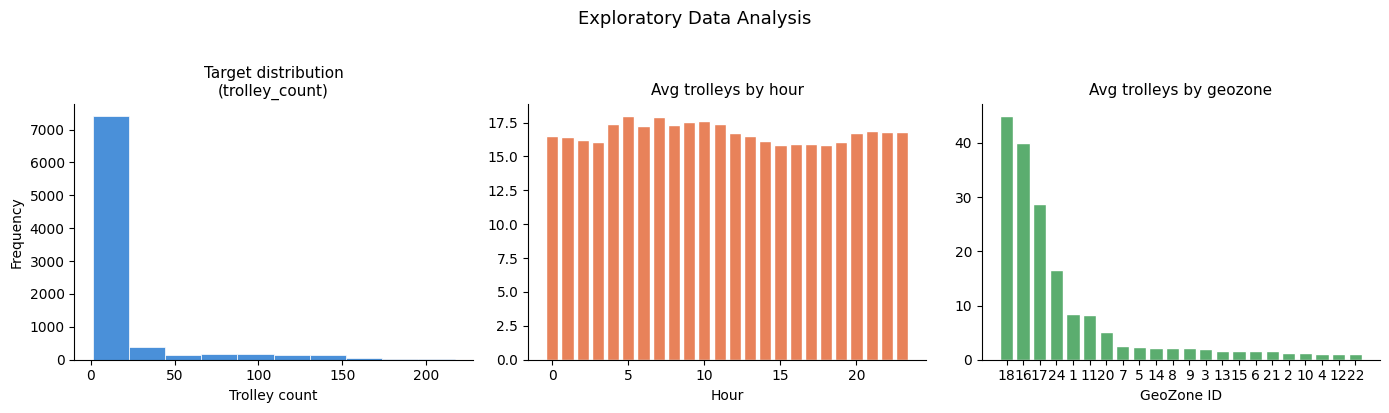

Target stats:
count    8655.00
mean       16.73
std        32.40
min         1.00
25%         2.00
50%         6.00
75%        11.00
max       217.00
Name: trolley_count, dtype: float64


In [125]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Distribution of trolley_count
axes[0].hist(y, bins=10, color='#4A90D9', edgecolor='white', linewidth=0.5)
axes[0].set_title('Target distribution\n(trolley_count)', fontsize=11)
axes[0].set_xlabel('Trolley count')
axes[0].set_ylabel('Frequency')
axes[0].spines[['top','right']].set_visible(False)

# Trolleys by hour
hour_avg = trolley_count.groupby('hour')['trolley_count'].mean()
axes[1].bar(hour_avg.index, hour_avg.values, color='#E8825A', edgecolor='white')
axes[1].set_title('Avg trolleys by hour', fontsize=11)
axes[1].set_xlabel('Hour')
axes[1].spines[['top','right']].set_visible(False)

# Trolleys by geozone
zone_avg = trolley_count.groupby('geozoneId')['trolley_count'].mean().sort_values(ascending=False)
axes[2].bar(zone_avg.index.astype(str), zone_avg.values, color='#5BAD6F', edgecolor='white')
axes[2].set_title('Avg trolleys by geozone', fontsize=11)
axes[2].set_xlabel('GeoZone ID')
axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('Exploratory Data Analysis', fontsize=13, fontweight='500', y=1.02)
plt.tight_layout()
plt.show()

print('Target stats:')
print(y.describe().round(2))

In [126]:
pip install lightgbm xgboost scikit-learn pandas numpy

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 9.2 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


# train test split 

In [142]:
trolley_count.head()

,date,day_of_week,day_num,is_weekend,hour,slot_start,geozoneId,geolayerId,trolley_count,month
0,2026-03-04,Wednesday,2,0,13,2026-03-04 13:00:00,2,3,3,3
1,2026-03-04,Wednesday,2,0,13,2026-03-04 13:00:00,4,4,1,3
2,2026-03-04,Wednesday,2,0,13,2026-03-04 13:00:00,11,7,10,3
3,2026-03-04,Wednesday,2,0,13,2026-03-04 13:00:00,16,11,1,3
4,2026-03-04,Wednesday,2,0,14,2026-03-04 14:00:00,2,3,10,3


In [140]:
X.head()

,day_num,is_weekend,hour,geozoneId,geolayerId,month
0,2,0,13,2,3,3
1,2,0,13,4,4,3
2,2,0,13,11,7,3
3,2,0,13,16,11,3
4,2,0,14,2,3,3


In [141]:
y.head()

0     3
1     1
2    10
3     1
4    10
Name: trolley_count, dtype: int64

In [128]:
from sklearn.model_selection import train_test_split, cross_val_score


In [129]:
TEST_SIZE    = 0.20
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42
)

In [ ]:
Xgb_boost.fit(X_train, y_train)

In [130]:
# ── All regression models
from sklearn.linear_model    import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import (
    RandomForestRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor, AdaBoostRegressor
)
from sklearn.neighbors       import KNeighborsRegressor
from sklearn.svm             import SVR
import xgboost  as xgb
import lightgbm as lgb

# ── Metrics
from sklearn.metrics import (
    r2_score, mean_absolute_error,
    mean_squared_error, mean_absolute_percentage_error
)

In [135]:
import numpy as np
results = []
MODELS = {
    'Linear Regression'   : {'model': LinearRegression(),                                              'scaled': True  },
    'Ridge'               : {'model': Ridge(alpha=1.0),                                                'scaled': True  },
    'Lasso'               : {'model': Lasso(alpha=0.1, max_iter=10000),                                'scaled': True  },
    'ElasticNet'          : {'model': ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),             'scaled': True  },
    'Decision Tree'       : {'model': DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE),   'scaled': False },
    'Random Forest'       : {'model': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, min_samples_leaf=1), 'scaled': False},
    'Gradient Boosting'   : {'model': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE), 'scaled': False},
    'XGBoost'             : {'model': xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE, verbosity=0), 'scaled': False},
    'LightGBM'            : {'model': lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE, verbose=-1, min_child_samples=1), 'scaled': False},
    'Extra Trees'         : {'model': ExtraTreesRegressor(n_estimators=100, random_state=RANDOM_STATE, min_samples_leaf=1), 'scaled': False},
    'AdaBoost'            : {'model': AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE), 'scaled': False},
    'KNN'                 : {'model': KNeighborsRegressor(n_neighbors=3),                              'scaled': True  },
    'SVR'                 : {'model': SVR(kernel='rbf', C=10, epsilon=0.5),                            'scaled': True  },
}

for name, cfg in MODELS.items():
    model = cfg['model']
    
    # Choose scaled or raw data
    Xtr = X_train
    Xte = X_test
    
    # ── Train
    model.fit(Xtr, y_train)
    
    # ── Predict on test set
    y_pred = model.predict(Xte)
    y_pred = np.clip(y_pred, 0, None)   # trolley count can't be negative
    
    # ── Compute metrics
    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    
    # MAPE: avoid div-by-zero if any y_test == 0
    mask = y_test != 0
    mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100 if mask.sum() > 0 else np.nan
    
    # ── 5-fold cross-validation R²  (on full dataset for stability with small data)
    Xfull = X
    cv_scores = cross_val_score(model, Xfull, y, cv=min(5, len(X)), scoring='r2')
    cv_r2 = cv_scores.mean()
    
    results.append({
        'Model'    : name,
        'R²'       : round(r2,   4),
        'MAE'      : round(mae,  4),
        'MSE'      : round(mse,  4),
        'RMSE'     : round(rmse, 4),
        'MAPE (%)'  : round(mape, 2) if not np.isnan(mape) else 'N/A',
        'CV R² (5-fold)': round(cv_r2, 4),
    })
    print(f'✅  {name:<22} | R²={r2:+.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}')

results_df = pd.DataFrame(results)

✅  Linear Regression      | R²=+0.2227  MAE=17.9778  RMSE=29.3754
✅  Ridge                  | R²=+0.2227  MAE=17.9775  RMSE=29.3755
✅  Lasso                  | R²=+0.2222  MAE=17.9484  RMSE=29.3847
✅  ElasticNet             | R²=+0.2199  MAE=17.8742  RMSE=29.4280
✅  Decision Tree          | R²=+0.7291  MAE=7.6443  RMSE=17.3435
✅  Random Forest          | R²=+0.7223  MAE=6.7001  RMSE=17.5586
✅  Gradient Boosting      | R²=+0.7272  MAE=7.9110  RMSE=17.4014
✅  XGBoost                | R²=+0.7710  MAE=6.8881  RMSE=15.9462
✅  LightGBM               | R²=+0.7698  MAE=6.5440  RMSE=15.9872
✅  Extra Trees            | R²=+0.6783  MAE=7.0252  RMSE=18.8976
✅  AdaBoost               | R²=+0.4567  MAE=13.1169  RMSE=24.5601
✅  KNN                    | R²=+0.5360  MAE=9.7408  RMSE=22.6951
✅  SVR                    | R²=-0.0107  MAE=13.5163  RMSE=33.4963


In [136]:
Xgb_boost= xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)

In [137]:
import joblib

In [139]:
joblib.dump(Xgb_boost,'final_xgbmodel_for_demand_forcast.pkl')

['final_xgbmodel_for_demand_forcast.pkl']